<a href="https://colab.research.google.com/github/yuvrajm4/261421_Introduction_To_ML_Safety/blob/main/exercise_solutions/Introduction_To_ML_Safety_Ex6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Explaining the CARLA Model

### 6.5: Applying an Explainability Method

Choose one local explainability method from the lecture: occlusion, CAM, Grad-CAM, or saliency maps. Apply it to each of your three CARLA models.

### 1. Briefly describe how your chosen method works and why you chose it.

### Method choice: Grad-CAM

--> Grad-CAM means Gradient-weighted Class Activation Mapping.

It explains one prediction by showing which image regions had the strongest influence on the model output. It uses: feature maps from the last convolution layer and gradients of the class score with respect to those feature maps


Grad-CAM shows where the CNN looked when making its prediction.

Reason for choosing Grad-CAM -  because our CARLA models are based on ResNet-18 CNNs, and Grad-CAM is suitable for CNN models. It is also better than basic CAM because it does not require a special architecture with global average pooling directly before the classifier. Grad-CAM is more generally applicable to CNNs because it uses gradients instead of only classifier weights.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import cv2
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score

Declare paths to the Google drive - models and test data

In [34]:
import os
TEST_DIR = "/content/drive/MyDrive/introduction_to_ml_safety/test"
print("Test folder exists:", os.path.exists(TEST_DIR))
MODEL_DIR = "/content/drive/MyDrive/introduction_to_ml_safety/trained_models"
PEDESTRIAN_MODEL_PATH = os.path.join(MODEL_DIR, "pedestrian_detector.pth")
TRAFFIC_LIGHT_MODEL_PATH = os.path.join(MODEL_DIR, "traffic_light_detector.pth")
VEHICLE_MODEL_PATH = os.path.join(MODEL_DIR, "vehicle_detector.pth")

test_df = pd.read_csv(TEST_DIR + "/labels.csv")

test_df.columns = [c.strip().lower() for c in test_df.columns]

display(test_df.head())

Test folder exists: True


,frame,has_traffic_light,has_pedestrian,has_vehicle,px_traffic_light,px_pedestrian,px_vehicle
0,0,False,False,False,15,0,35
1,10,True,False,True,299,0,116
2,20,True,False,True,298,0,307
3,30,True,False,True,297,0,258
4,40,True,False,True,297,0,249


In [ ]:
def build_image_path(root_dir, frame):
    filename = f"{int(frame):06d}.jpg"
    return os.path.join(root_dir, "rgb-front", filename)

In [ ]:
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

Load Models using GPU - Use weights=None because we are loading our own saved weights.

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

def create_model():
    model = models.resnet18(weights=None)
    num_features = model.fc.in_features
    model.fc = nn.Linear(num_features, 1)
    model = model.to(device)
    return model

Using device: cuda


In [ ]:
pedestrian_model = create_model()
pedestrian_model.load_state_dict(torch.load(PEDESTRIAN_MODEL_PATH, map_location=device))
pedestrian_model.eval()

traffic_light_model = create_model()
traffic_light_model.load_state_dict(torch.load(TRAFFIC_LIGHT_MODEL_PATH, map_location=device))
traffic_light_model.eval()

vehicle_model = create_model()
vehicle_model.load_state_dict(torch.load(VEHICLE_MODEL_PATH, map_location=device))
vehicle_model.eval()

print("All models loaded.")

All models loaded.


GradCAM class instantiate

In [ ]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer

        self.gradients = None
        self.activations = None

        self.forward_hook = target_layer.register_forward_hook(self.save_activation)
        self.backward_hook = target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output.detach()

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor):
        self.model.zero_grad()

        output = self.model(input_tensor)

        # Binary classifier: one logit
        score = output[0, 0]

        score.backward()

        gradients = self.gradients[0]
        activations = self.activations[0]

        weights = gradients.mean(dim=(1, 2))

        cam = torch.zeros(activations.shape[1:], dtype=torch.float32).to(device)

        for i, w in enumerate(weights):
            cam += w * activations[i]

        cam = torch.relu(cam)

        cam = cam.cpu().numpy()

        cam = cam - np.min(cam)

        if np.max(cam) != 0:
            cam = cam / np.max(cam)

        return cam

Heatmap Overlay Function

In [ ]:
def overlay_gradcam(original_image, cam):
    original_image = original_image.resize((224, 224))

    img_np = np.array(original_image)

    cam_resized = cv2.resize(cam, (224, 224))

    heatmap = cv2.applyColorMap(
        np.uint8(255 * cam_resized),
        cv2.COLORMAP_JET
    )

    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    overlay = 0.6 * img_np + 0.4 * heatmap
    overlay = np.uint8(overlay)

    return overlay

Function for Prediction - takes model and image as inputs

In [ ]:
def predict_single_image(model, image_path):
    image = Image.open(image_path).convert("RGB")
    input_tensor = test_transform(image).unsqueeze(0).to(device)

    model.eval()

    with torch.no_grad():
        logit = model(input_tensor)
        prob = torch.sigmoid(logit).item()
        pred = int(prob > 0.5)

    return pred, prob

Find correctly classified and misclassified images - Appending Predictions in a pre-defined dictionary

In [ ]:
def collect_predictions(model, label_column, model_name):
    records = []

    for idx, row in test_df.iterrows():
        image_path = build_image_path(TEST_DIR, row["frame"])

        true_label = int(row[label_column])
        pred, prob = predict_single_image(model, image_path)

        records.append({
            "index": idx,
            "frame": row["frame"],
            "image_path": image_path,
            "model": model_name,
            "label_column": label_column,
            "true_label": true_label,
            "prediction": pred,
            "probability": prob,
            "correct": true_label == pred
        })

    return pd.DataFrame(records)

In [26]:
ped_results = collect_predictions(
    pedestrian_model,
    "has_pedestrian",
    "Pedestrian Detector"
)

tl_results = collect_predictions(
    traffic_light_model,
    "has_traffic_light",
    "Traffic Light Detector"
)

veh_results = collect_predictions(
    vehicle_model,
    "has_vehicle",
    "Vehicle Detector"
)

### 2. Select five correctly classified images - at least one per model. Visualize the explanation (heatmap or sensitivity map) overlaid on the original image.

In [27]:
correct_examples = pd.concat([
    ped_results[ped_results["correct"] == True].head(2),
    tl_results[tl_results["correct"] == True].head(2),
    veh_results[veh_results["correct"] == True].head(1)
])

display(correct_examples)

,index,frame,image_path,model,label_column,true_label,prediction,probability,correct
0,0,0,/content/drive/MyDrive/introduction_to_ml_safe...,Pedestrian Detector,has_pedestrian,0,0,0.001045,True
1,1,10,/content/drive/MyDrive/introduction_to_ml_safe...,Pedestrian Detector,has_pedestrian,0,0,0.000174,True
0,0,0,/content/drive/MyDrive/introduction_to_ml_safe...,Traffic Light Detector,has_traffic_light,0,0,0.000499,True
1,1,10,/content/drive/MyDrive/introduction_to_ml_safe...,Traffic Light Detector,has_traffic_light,1,1,0.999993,True
0,0,0,/content/drive/MyDrive/introduction_to_ml_safe...,Vehicle Detector,has_vehicle,0,0,0.150282,True


Select 3 misclassified images

In [28]:
misclassified_examples = pd.concat([
    ped_results[ped_results["correct"] == False].head(1),
    tl_results[tl_results["correct"] == False].head(1),
    veh_results[veh_results["correct"] == False].head(1)
])

display(misclassified_examples)

,index,frame,image_path,model,label_column,true_label,prediction,probability,correct
46,46,460,/content/drive/MyDrive/introduction_to_ml_safe...,Pedestrian Detector,has_pedestrian,0,1,0.549958,False
13,13,130,/content/drive/MyDrive/introduction_to_ml_safe...,Traffic Light Detector,has_traffic_light,0,1,0.898010,False
14,14,140,/content/drive/MyDrive/introduction_to_ml_safe...,Vehicle Detector,has_vehicle,0,1,0.999776,False


In [29]:
def get_model_by_name(model_name):
    if model_name == "Pedestrian Detector":
        return pedestrian_model
    elif model_name == "Traffic Light Detector":
        return traffic_light_model
    elif model_name == "Vehicle Detector":
        return vehicle_model
    else:
        raise ValueError("Unknown model name")

Visualise Function

In [31]:
def visualize_gradcam_for_examples(examples_df, title_prefix):
    for _, row in examples_df.iterrows():

        model = get_model_by_name(row["model"])
        target_layer = model.layer4[-1]

        gradcam = GradCAM(model, target_layer)

        image_path = row["image_path"]
        original_image = Image.open(image_path).convert("RGB")

        input_tensor = test_transform(original_image).unsqueeze(0).to(device)

        cam = gradcam.generate(input_tensor)

        overlay = overlay_gradcam(original_image, cam)

        plt.figure(figsize=(10, 4))

        plt.subplot(1, 2, 1)
        plt.imshow(original_image.resize((224, 224)))
        plt.title("Original Image")
        plt.axis("off")

        plt.subplot(1, 2, 2)
        plt.imshow(overlay)
        plt.title(
            f"{title_prefix}\n"
            f"{row['model']}\n"
            f"True: {row['true_label']} | Pred: {row['prediction']} | Prob: {row['probability']:.3f}"
        )
        plt.axis("off")

        plt.show()

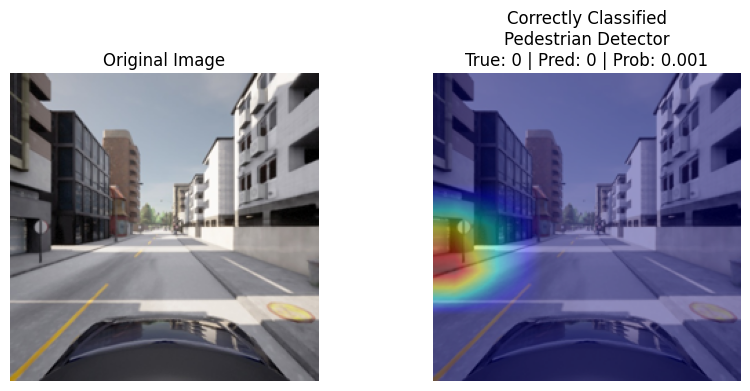

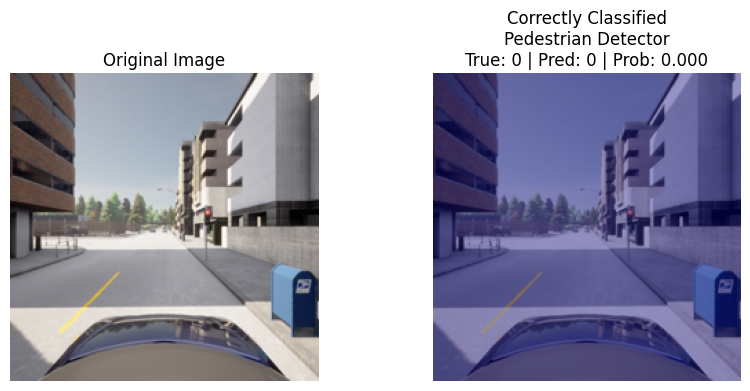

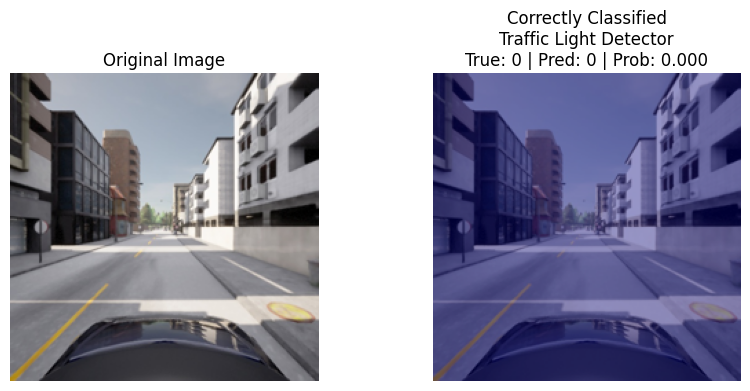

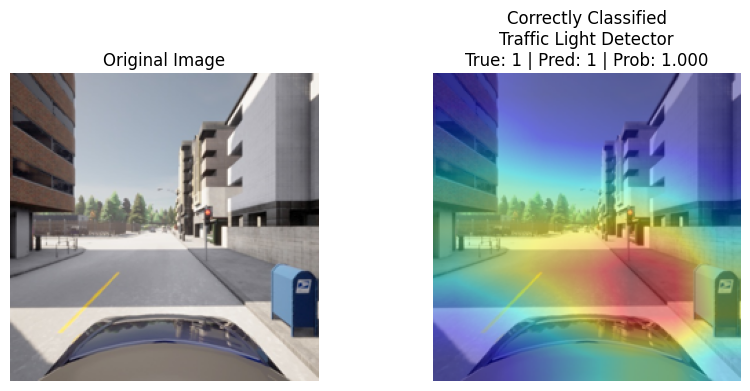

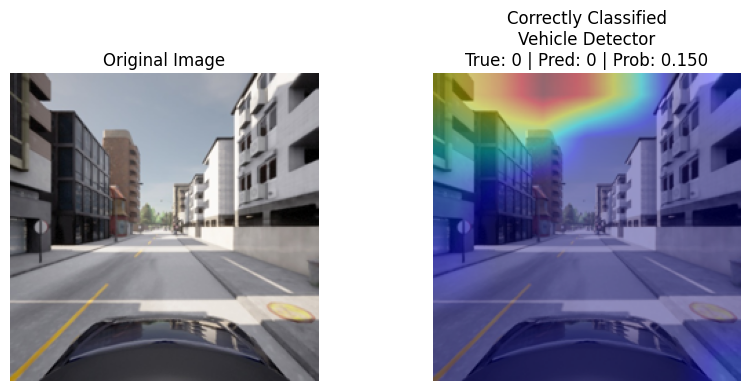

In [32]:
visualize_gradcam_for_examples(
    correct_examples,
    "Correctly Classified"
)

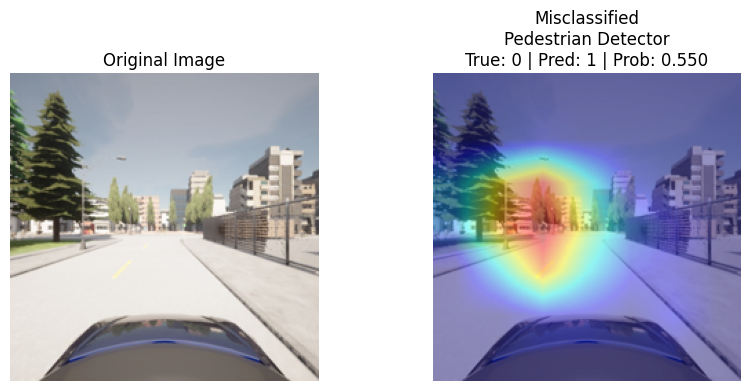

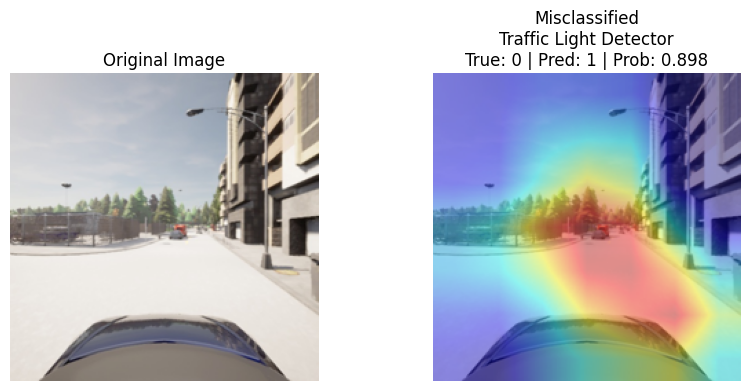

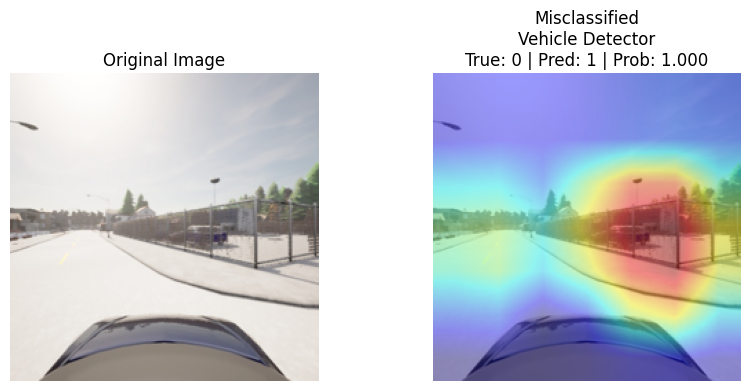

In [33]:
visualize_gradcam_for_examples(
    misclassified_examples,
    "Misclassified"
)

### 3. Do the highlighted regions correspond to the relevant objects (e.g., does the map highlight the pedestrian when the model predicts “pedestrian present”)?


--> Only partly.

For some negative examples, the model correctly predicts that the object is absent, so it is not necessary for the heatmap to highlight a specific pedestrian, traffic light, or vehicle. In these cases, weak or scattered heatmaps are acceptable.

However, in the positive traffic light example, the model predicts traffic light present with high confidence, but the highlighted region does not clearly focus on the traffic light itself. Instead, the heatmap appears to focus more on road or lower image regions. This suggests that the model may be using contextual or background features instead of only the actual traffic light.
So, the Grad-CAM results give mixed evidence. Some correct predictions seem reasonable, but some heatmaps suggest possible shortcut learning.


### 4. Select three misclassified images and apply the same method. Do the explanations give any insight into why the model failed?

--> For misclassified images, the Grad-CAM heatmaps were more informative. The pedestrian detector falsely predicted a pedestrian while focusing on the road/sidewalk area. The traffic light detector falsely predicted a traffic light while focusing on the central road/building region. The vehicle detector falsely predicted a vehicle with very high confidence while focusing on the right-side fence/background area. These results suggest that the models may rely on spurious background features instead of consistently focusing on the safety-relevant objects. Therefore, Grad-CAM is useful for debugging model behaviour, but the heatmaps should be treated as supporting evidence, not as a formal proof of safety.

### 6.6: Explainability as a Diagnostic Tool

### Now test your models on images from different conditions than the ones they were trained on - for example a different town layout, nighttime, or foggy weather. Apply the same explanation method as before.

(a) Do the highlighted regions still correspond to the relevant objects?

Download the different test datasets

In [35]:
DATASET_ROOT = "/content/drive/MyDrive/introduction_to_ml_safety"
os.makedirs(DATASET_ROOT, exist_ok=True)


!wget -q -O /content/drive/MyDrive/introduction_to_ml_safety/test-fog.zip "https://cloud.ovgu.de/s/fYD35gBQA7Ykqom/download?path=%2F&files=test-fog.zip"
!wget -q -O /content/drive/MyDrive/introduction_to_ml_safety/test-night.zip "https://cloud.ovgu.de/s/fYD35gBQA7Ykqom/download?path=%2F&files=test-night.zip"
!wget -q -O /content/drive/MyDrive/introduction_to_ml_safety/test-town-01.zip "https://cloud.ovgu.de/s/fYD35gBQA7Ykqom/download?path=%2F&files=test-town-01.zip"



print("Download finished.")

Download finished.


Extract new datasets

In [36]:
TEST_FOG_ZIP = os.path.join(DATASET_ROOT, "test-fog.zip")
TEST_NIGHT_ZIP = os.path.join(DATASET_ROOT, "test-night.zip")
TEST_TOWN_ZIP = os.path.join(DATASET_ROOT, "test-town-01.zip")


!unzip -q -o "$TEST_FOG_ZIP" -d /content/drive/MyDrive/introduction_to_ml_safety/
!unzip -q -o "$TEST_NIGHT_ZIP" -d /content/drive/MyDrive/introduction_to_ml_safety/
!unzip -q -o "$TEST_TOWN_ZIP" -d /content/drive/MyDrive/introduction_to_ml_safety/

In [42]:
TEST_FOG_DIR = "/content/drive/MyDrive/introduction_to_ml_safety/test-fog"
TEST_NIGHT_DIR = "/content/drive/MyDrive/introduction_to_ml_safety/test-night"
TEST_TOWN_DIR = "/content/drive/MyDrive/introduction_to_ml_safety/test-town-01"

CONDITION_DIRS = {
    "Original": TEST_DIR,
    "Fog": TEST_FOG_DIR,
    "Night": TEST_NIGHT_DIR,
    "Different Town": TEST_TOWN_DIR
}

In [43]:
for condition_name, condition_dir in CONDITION_DIRS.items():
    print("\nCondition:", condition_name)
    print("Folder:", condition_dir)
    print("Labels exist:", os.path.exists(os.path.join(condition_dir, "labels.csv")))
    print("rgb-front exists:", os.path.exists(os.path.join(condition_dir, "rgb-front")))


Condition: Original
Folder: /content/drive/MyDrive/introduction_to_ml_safety/test
Labels exist: True
rgb-front exists: True

Condition: Fog
Folder: /content/drive/MyDrive/introduction_to_ml_safety/test-fog
Labels exist: True
rgb-front exists: True

Condition: Night
Folder: /content/drive/MyDrive/introduction_to_ml_safety/test-night
Labels exist: True
rgb-front exists: True

Condition: Different Town
Folder: /content/drive/MyDrive/introduction_to_ml_safety/test-town-01
Labels exist: True
rgb-front exists: True


In [46]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_model_on_condition(model, condition_dir, label_column):
    df = pd.read_csv(os.path.join(condition_dir, "labels.csv"))
    df.columns = [c.strip().lower() for c in df.columns]

    all_labels = []
    all_preds = []

    for _, row in df.iterrows():
        image_path = build_image_path(condition_dir, row["frame"])

        true_label = int(row[label_column])

        # Do not pass threshold here
        pred, prob = predict_single_image(model, image_path)

        all_labels.append(true_label)
        all_preds.append(pred)

    return {
        "Accuracy": accuracy_score(all_labels, all_preds),
        "Precision": precision_score(all_labels, all_preds, zero_division=0),
        "Recall": recall_score(all_labels, all_preds, zero_division=0),
        "F1": f1_score(all_labels, all_preds, zero_division=0)
    }

In [47]:
condition_results = []

models_info = [
    ("Pedestrian Detector", pedestrian_model, "has_pedestrian"),
    ("Traffic Light Detector", traffic_light_model, "has_traffic_light"),
    ("Vehicle Detector", vehicle_model, "has_vehicle")
]

for condition_name, condition_dir in CONDITION_DIRS.items():
    for model_name, model, label_column in models_info:
        metrics = evaluate_model_on_condition(
            model=model,
            condition_dir=condition_dir,
            label_column=label_column
        )

        condition_results.append({
            "Condition": condition_name,
            "Model": model_name,
            **metrics
        })

condition_results_df = pd.DataFrame(condition_results)
display(condition_results_df)

,Condition,Model,Accuracy,Precision,Recall,F1
0,Original,Pedestrian Detector,0.790000,0.452652,0.338527,0.387358
1,Original,Traffic Light Detector,0.936667,0.941860,0.971749,0.956571
2,Original,Vehicle Detector,0.886111,0.955812,0.889259,0.921335
3,Fog,Pedestrian Detector,0.805556,0.646018,0.099591,0.172577
4,Fog,Traffic Light Detector,0.557222,0.969091,0.405941,0.572195
5,Fog,Vehicle Detector,0.655556,0.993610,0.558348,0.714943
6,Night,Pedestrian Detector,0.650556,0.277119,0.446721,0.342050
7,Night,Traffic Light Detector,0.271111,1.000000,0.001142,0.002281
8,Night,Vehicle Detector,0.760278,0.947393,0.730700,0.825056
9,Different Town,Pedestrian Detector,0.757778,0.159402,0.393846,0.226950


In [48]:
def collect_predictions_for_condition(model, label_column, model_name, condition_name, condition_dir):
    df = pd.read_csv(os.path.join(condition_dir, "labels.csv"))
    df.columns = [c.strip().lower() for c in df.columns]

    records = []

    for idx, row in df.iterrows():
        image_path = build_image_path(condition_dir, row["frame"])

        true_label = int(row[label_column])
        pred, prob = predict_single_image(model, image_path)

        records.append({
            "index": idx,
            "frame": row["frame"],
            "image_path": image_path,
            "condition": condition_name,
            "model": model_name,
            "label_column": label_column,
            "true_label": true_label,
            "prediction": pred,
            "probability": prob,
            "correct": true_label == pred
        })

    return pd.DataFrame(records)

In [49]:
shifted_results = []

for condition_name, condition_dir in {
    "Fog": TEST_FOG_DIR,
    "Night": TEST_NIGHT_DIR,
    "Different Town": TEST_TOWN_DIR
}.items():

    shifted_results.append(
        collect_predictions_for_condition(
            pedestrian_model,
            "has_pedestrian",
            "Pedestrian Detector",
            condition_name,
            condition_dir
        )
    )

    shifted_results.append(
        collect_predictions_for_condition(
            traffic_light_model,
            "has_traffic_light",
            "Traffic Light Detector",
            condition_name,
            condition_dir
        )
    )

    shifted_results.append(
        collect_predictions_for_condition(
            vehicle_model,
            "has_vehicle",
            "Vehicle Detector",
            condition_name,
            condition_dir
        )
    )

shifted_results_df = pd.concat(shifted_results)
display(shifted_results_df.head())

,index,frame,image_path,condition,model,label_column,true_label,prediction,probability,correct
0,0,0,/content/drive/MyDrive/introduction_to_ml_safe...,Fog,Pedestrian Detector,has_pedestrian,0,0,0.002093,True
1,1,10,/content/drive/MyDrive/introduction_to_ml_safe...,Fog,Pedestrian Detector,has_pedestrian,0,0,0.001750,True
2,2,20,/content/drive/MyDrive/introduction_to_ml_safe...,Fog,Pedestrian Detector,has_pedestrian,0,0,0.001658,True
3,3,30,/content/drive/MyDrive/introduction_to_ml_safe...,Fog,Pedestrian Detector,has_pedestrian,0,0,0.001119,True
4,4,40,/content/drive/MyDrive/introduction_to_ml_safe...,Fog,Pedestrian Detector,has_pedestrian,0,0,0.001276,True


In [50]:
shifted_examples = pd.concat([
    shifted_results_df[
        (shifted_results_df["condition"] == "Fog") &
        (shifted_results_df["correct"] == True)
    ].head(1),

    shifted_results_df[
        (shifted_results_df["condition"] == "Night") &
        (shifted_results_df["correct"] == True)
    ].head(1),

    shifted_results_df[
        (shifted_results_df["condition"] == "Different Town") &
        (shifted_results_df["correct"] == True)
    ].head(1),

    shifted_results_df[
        (shifted_results_df["correct"] == False)
    ].head(3)
])

display(shifted_examples)

,index,frame,image_path,condition,model,label_column,true_label,prediction,probability,correct
0,0,0,/content/drive/MyDrive/introduction_to_ml_safe...,Fog,Pedestrian Detector,has_pedestrian,0,0,0.002093,True
0,0,0,/content/drive/MyDrive/introduction_to_ml_safe...,Night,Pedestrian Detector,has_pedestrian,0,0,0.103102,True
0,0,0,/content/drive/MyDrive/introduction_to_ml_safe...,Different Town,Pedestrian Detector,has_pedestrian,0,0,0.320752,True
74,74,740,/content/drive/MyDrive/introduction_to_ml_safe...,Fog,Pedestrian Detector,has_pedestrian,0,1,0.670628,False
105,105,1050,/content/drive/MyDrive/introduction_to_ml_safe...,Fog,Pedestrian Detector,has_pedestrian,1,0,0.071671,False
106,106,1060,/content/drive/MyDrive/introduction_to_ml_safe...,Fog,Pedestrian Detector,has_pedestrian,1,0,0.066095,False


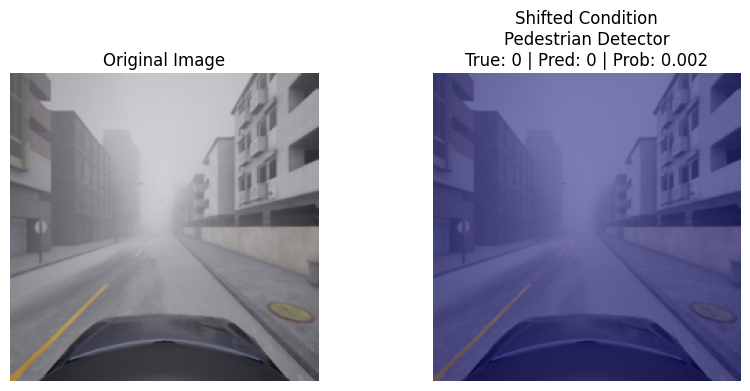

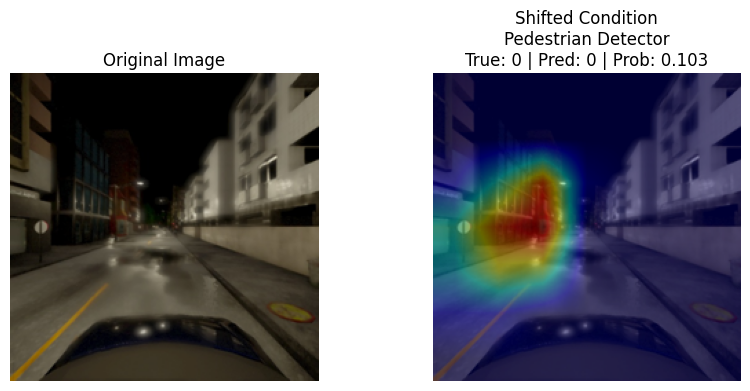

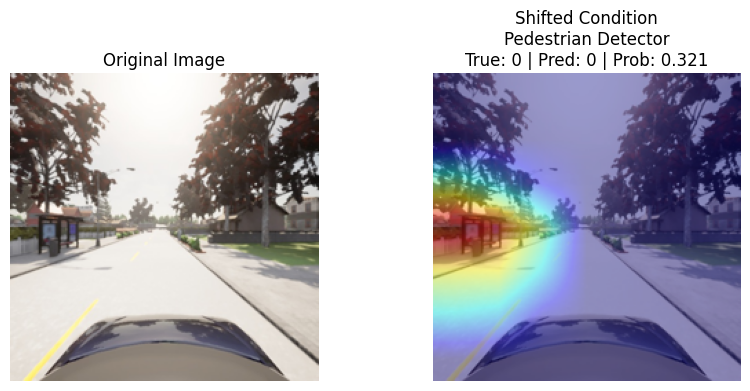

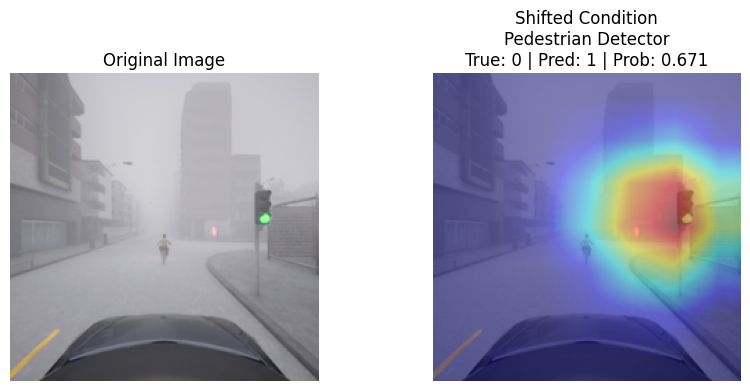

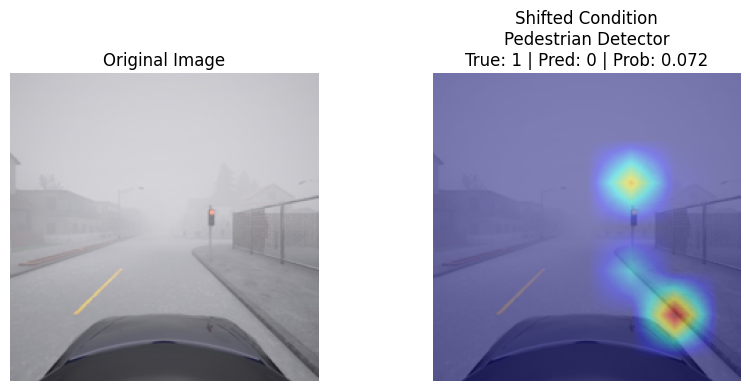

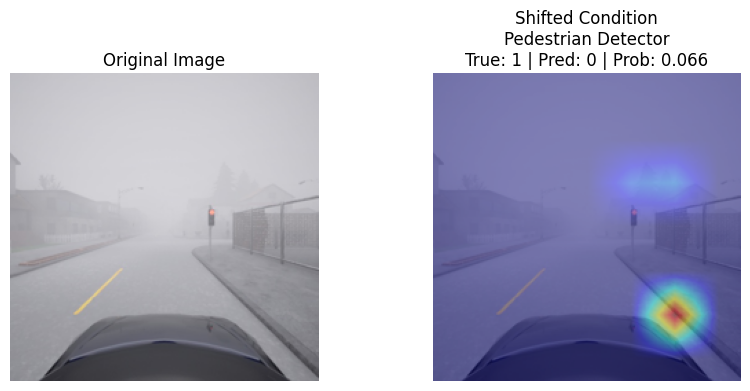

In [51]:
visualize_gradcam_for_examples(
    shifted_examples,
    "Shifted Condition"
)

### (a) Do the highlighted regions still correspond to the relevant objects?




-->
Based on the Grad-CAM images, the highlighted regions do not consistently correspond to the relevant objects.


### (b) Do you observe evidence that the model relied on background or spurious features (lighting, road texture, sky color) that are specific to the original training conditions?

-->

Yes, there is evidence that the model relies on background or spurious features.

In the shifted-condition Grad-CAM outputs, the highlighted regions often appear on:


Road surface --	Road texture or lane pattern
Sky / foggy background --	Weather and brightness shortcut
Buildings --	Town-specific layout
Traffic light area --	Confusion between pedestrian and traffic-light context
Fence / sidewalk --	Background structure instead of object
Bright regions at night --	Lighting artifact

### (c) How do the model’s accuracy and explanation quality change across conditions?

-->

The models were tested on fog, night, and different-town datasets. The results show clear performance degradation under shifted conditions. The pedestrian detector performs especially poorly in fog, where recall drops from 0.3385 on the original test set to 0.0996. This means that the model misses most pedestrians in fog. The traffic light detector performs well on the original test set, with recall 0.9717, but almost completely fails at night, where recall drops to 0.0011. The vehicle detector is more robust than the other two models, but its recall also drops in fog from 0.8893 to 0.5583.

The Grad-CAM explanations also become less reliable under shifted conditions. In several examples, the highlighted regions do not correspond to the relevant object. Instead, the heatmaps often focus on road areas, buildings, traffic-light regions, foggy background, or other scene context. This gives evidence that the models sometimes rely on spurious features specific to the original training conditions. Overall, both the metric results and the explanations indicate that the models do not generalize safely across ODD shifts such as fog, nighttime, and different town layouts.